In [1]:
import pandas as pd

train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')


In [2]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
train_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
train_df['Age'] = train_df['Age'].fillna(train_df['Age'].median())
train_df['Age'].head(10)

0    22.0
1    38.0
2    26.0
3    35.0
4    35.0
5    28.0
6    54.0
7     2.0
8    27.0
9    14.0
Name: Age, dtype: float64

In [5]:
train_df['Deck'] = train_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
train_df['Deck'].value_counts()
 
train_df = train_df.drop('Cabin', axis=1)
train_df.isnull().sum()


SyntaxError: invalid non-printable character U+00A0 (1704340074.py, line 3)

In [ ]:
train_df['Deck'] = train_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
train_df['Deck'].value_counts()
 
train_df = train_df.drop('Cabin', axis=1)
train_df.isnull().sum()


In [7]:
train_df['Deck'] = train_df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
train_df['Deck'].value_counts()

train_df = train_df.drop('Cabin', axis=1)
train_df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
Deck           0
dtype: int64

In [8]:
train_df['Embarked'] = train_df['Embarked'].fillna(train_df['Embarked'].mode()[0])
train_df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [9]:
numeric_cols = train_df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    outliers = train_df[(train_df[col] < Q1 - 1.5*IQR) | (train_df[col] > Q3 + 1.5*IQR)]
    
    print(col, "outliers:", len(outliers))


PassengerId outliers: 0
Survived outliers: 0
Pclass outliers: 0
Age outliers: 66
SibSp outliers: 46
Parch outliers: 213
Fare outliers: 116


In [10]:
upper_limit = train_df['Fare'].quantile(0.99)
train_df['Fare'] = np.where(train_df['Fare'] > upper_limit, upper_limit, train_df['Fare'])

train_df['Fare_log'] = np.log1p(train_df['Fare'])

NameError: name 'np' is not defined

In [11]:
import numpy as np

upper_limit = train_df['Fare'].quantile(0.99)
train_df['Fare'] = np.where(train_df['Fare'] > upper_limit, upper_limit, train_df['Fare'])

train_df['Fare_log'] = np.log1p(train_df['Fare'])

In [12]:
train_df['Fare'].describe()

count    891.000000
mean      31.224767
std       42.524125
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      249.006220
Name: Fare, dtype: float64

In [13]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Fare_log
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,U,2.110213
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,4.280593
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,U,2.188856
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,3.990834
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,U,2.202765


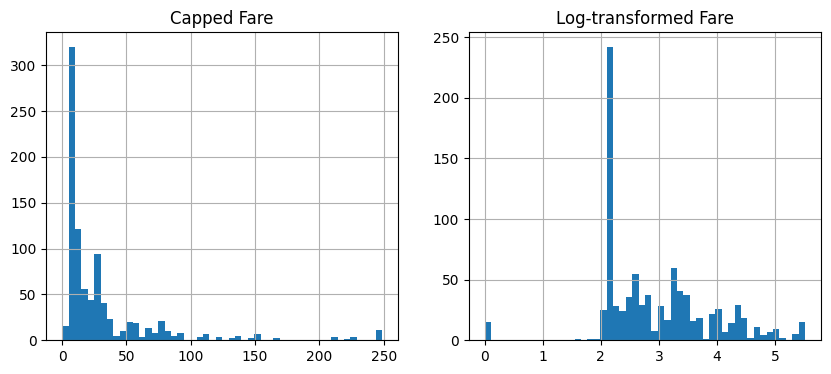

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
train_df['Fare'].hist(bins=50)
plt.title('Capped Fare')

plt.subplot(1,2,2)
train_df['Fare_log'].hist(bins=50)
plt.title('Log-transformed Fare')

plt.show()

In [15]:
train_df.duplicated().sum()

np.int64(0)

In [16]:
train_df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [17]:
train_df['Embarked'].value_counts()

Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

In [18]:
train_df['Name'].head(10)        
train_df['Name'].sample(10)      

251         Strom, Mrs. Wilhelm (Elna Matilda Persson)
867               Roebling, Mr. Washington Augustus II
27                      Fortune, Mr. Charles Alexander
165    Goldsmith, Master. Frank John William "Frankie"
376                    Landergren, Miss. Aurora Adelia
643                                    Foo, Mr. Choong
511                                  Webber, Mr. James
158                                Smiljanic, Mr. Mile
811                                  Lester, Mr. James
109                                Moran, Miss. Bertha
Name: Name, dtype: str

In [19]:
train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
train_df['Title'].value_counts()


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Byron\AppData\Local\Temp\ipykernel_4884\2804912004.py:1: SyntaxWarning: invalid escape sequence '\.'
  train_df['Title'] = train_df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [20]:
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
train_df['Title'] = train_df['Title'].replace(rare_titles, 'Rare')

In [21]:
train_df['Title'].describe()

count     891
unique      8
top        Mr
freq      517
Name: Title, dtype: object

In [22]:
train_df['Title'].sample(10)

6          Mr
686        Mr
63     Master
704        Mr
97         Mr
599      Rare
24       Miss
18        Mrs
590        Mr
834        Mr
Name: Title, dtype: str

In [23]:
train_df.to_csv('../data/train_cleaned.csv', index=False)

In [24]:
cleaned_df = pd.read_csv('../data/train_cleaned.csv')
cleaned_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Fare_log,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,U,2.110213,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,C,4.280593,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,U,2.188856,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,C,3.990834,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,U,2.202765,Mr


In [25]:
cleaned_df.sample(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck,Fare_log,Title
385,386,0,2,"Davies, Mr. Charles Henry",male,18.0,0,0,S.O.C. 14879,73.500,S,U,4.310799,Mr
443,444,1,2,"Reynaldo, Ms. Encarnacion",female,28.0,0,0,230434,13.000,S,U,2.639057,Ms
86,87,0,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.375,S,U,3.566005,Mr
427,428,1,2,"Phillips, Miss. Kate Florence (""Mrs Kate Louis...",female,19.0,0,0,250655,26.000,S,U,3.295837,Miss
109,110,1,3,"Moran, Miss. Bertha",female,28.0,1,0,371110,24.150,Q,U,3.224858,Miss


In [ ]:
feature_df = pd.read_csv('../data/train_cleaned.csv')
feature_df.head()


In [ ]:
feature_df['FamilySize'] = feature_df['SibSp'] + feature_df['Parch'] + 1
feature_df['IsAlone'] = (feature_df['FamilySize'] == 1).astype(int)
feature_df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()


In [ ]:
feature_df['Title'] = feature_df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
feature_df['Title'].value_counts()


In [ ]:
feature_df['AgeGroup'] = pd.cut(
    feature_df['Age'],
    bins=[0, 12, 19, 59, float('inf')],
    labels=['Child', 'Teen', 'Adult', 'Senior'],
    include_lowest=True
)
feature_df[['Age', 'AgeGroup']].sample(10)


In [ ]:
feature_df['TicketPrefix'] = (
    feature_df['Ticket']
    .astype(str)
    .str.replace(r'\d+', '', regex=True)
    .str.replace(r'[./]', '', regex=True)
    .str.replace(' ', '', regex=False)
    .replace('', 'NUM')
)
feature_df['FarePerPerson'] = feature_df['Fare'] / feature_df['FamilySize']
feature_df[['Ticket', 'TicketPrefix', 'Fare', 'FamilySize', 'FarePerPerson']].head()


In [ ]:
feature_df.to_csv('../data/train_featured.csv', index=False)


In [ ]:
featured_df = pd.read_csv('../data/train_featured.csv')
featured_df.head()


In [ ]:
model_df = featured_df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare_log', 'Embarked', 'Deck', 'Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FarePerPerson']].copy()
model_df = pd.get_dummies(model_df, columns=['Sex', 'Embarked', 'Deck', 'Title', 'AgeGroup'], drop_first=True)
model_df.head()


In [ ]:
X = model_df.drop('Survived', axis=1)
y = model_df['Survived']
correlations = model_df.corr(numeric_only=True)['Survived'].sort_values(ascending=False)
correlations


In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

selector = SelectKBest(score_func=mutual_info_classif, k=10)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
selected_features


In [ ]:
selected_df = pd.concat([y, X[selected_features]], axis=1)
selected_df.head()


In [ ]:
selected_df.to_csv('../data/train_selected.csv', index=False)
